# Análise Temporal Completa: Múltiplas Perspectivas

## 📊 Objetivo

Analisar o comportamento temporal de **TODAS as classificações** sob **múltiplas perspectivas**:

1. **Números Absolutos** → Volume real (comunicação)
2. **Percentuais** → Satisfação relativa (pesquisa)
3. **Índice Base 100** → Taxa de crescimento comparável
4. **Taxa de Crescimento** → Variação mês a mês
5. **Média Móvel** → Tendência de longo prazo
6. **Z-Score** → Comparação de escalas diferentes

## 🎯 Por que Múltiplas Perspectivas?

**Problema**: Pesquisa diz "melhorou", Comunicação diz "piorou"

**Solução**: Cada perspectiva responde uma pergunta diferente:
- Absolutos → "Quantas reclamações?"
- Percentuais → "Qual proporção?"
- Índice → "Qual cresce mais rápido?"
- Taxa → "Mudança foi abrupta?"
- Média móvel → "Tendência real ou ruído?"

---

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

# Configuração
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (18, 6)
plt.rcParams['font.size'] = 11
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✅ Bibliotecas carregadas")

✅ Bibliotecas carregadas


## 1. Carregar e Preparar Dados

In [2]:
# URL
url = "https://docs.google.com/spreadsheets/d/1LmMi0mTTzRytJno0EHu8P873wcPpQavktO_D_FFXA1E/export?format=xlsx&gid=1312481019"

# Carregar
df = pd.read_excel(url, engine='openpyxl')
df['Data'] = pd.to_datetime(df['Data'], errors='coerce')
df['Ano_Mes'] = df['Data'].dt.to_period('M')

print(f"✅ {len(df):,} registros carregados")

✅ 12,317 registros carregados


In [3]:
# Criar dataset temporal
temporal_all = df.groupby(['Ano_Mes', 'Classificação']).size().unstack(fill_value=0)
temporal_all = temporal_all.reset_index()
temporal_all['Data'] = temporal_all['Ano_Mes'].dt.to_timestamp()

# Garantir colunas
for col in ['POSITIVA', 'NEUTRA', 'NEGATIVA', 'PUBLICIDADE']:
    if col not in temporal_all.columns:
        temporal_all[col] = 0

# Totais
temporal_all['Total_Geral'] = temporal_all[['POSITIVA', 'NEUTRA', 'NEGATIVA', 'PUBLICIDADE']].sum(axis=1)
temporal_all['Total_Sentimento'] = temporal_all[['POSITIVA', 'NEUTRA', 'NEGATIVA']].sum(axis=1)

print("✅ Dataset temporal criado")
print(f"   Período: {temporal_all['Ano_Mes'].min()} a {temporal_all['Ano_Mes'].max()}")
print(f"   Total de meses: {len(temporal_all)}")

✅ Dataset temporal criado
   Período: 2024-03 a 2025-03
   Total de meses: 13


## 2. PERSPECTIVA 1: Números Absolutos

**Responde:** "Quantos comentários de cada tipo?"

**Para quem:** Equipe de comunicação

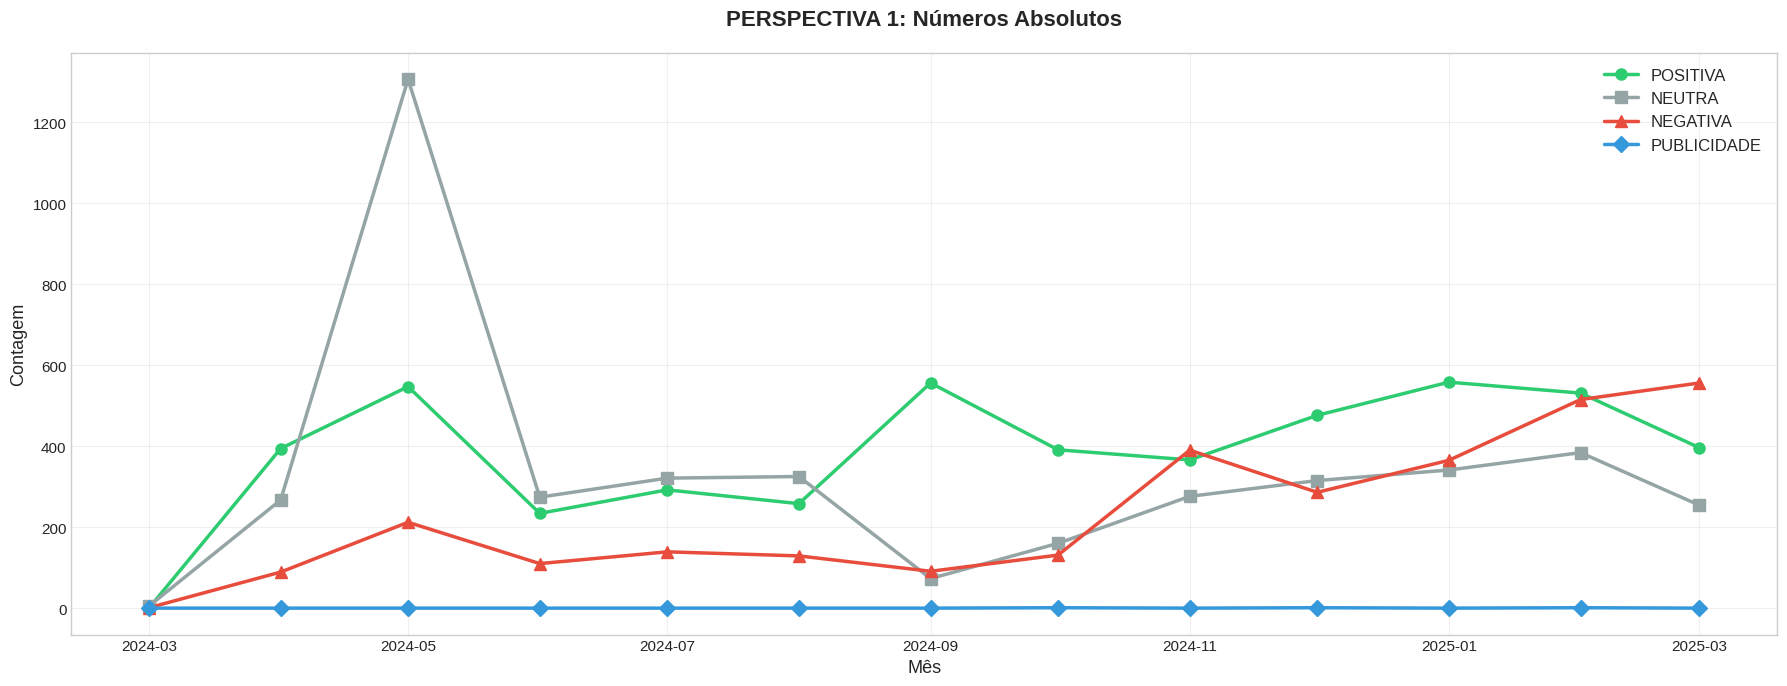

💡 INTERPRETAÇÃO:
   Mostra VOLUME real
   Se NEGATIVA subiu de 500→800: +300 reclamações absolutas
   Comunicação vê isso e diz 'piorou'


In [4]:
fig, ax = plt.subplots(figsize=(18, 7))

ax.plot(temporal_all['Data'], temporal_all['POSITIVA'], 
        marker='o', linewidth=2.5, markersize=8, color='#2ecc71', label='POSITIVA')
ax.plot(temporal_all['Data'], temporal_all['NEUTRA'], 
        marker='s', linewidth=2.5, markersize=8, color='#95a5a6', label='NEUTRA')
ax.plot(temporal_all['Data'], temporal_all['NEGATIVA'], 
        marker='^', linewidth=2.5, markersize=8, color='#e74c3c', label='NEGATIVA')
ax.plot(temporal_all['Data'], temporal_all['PUBLICIDADE'], 
        marker='D', linewidth=2.5, markersize=8, color='#3498db', label='PUBLICIDADE')

setembro_2025_ts = pd.Timestamp('2025-09-01')
if setembro_2025_ts in temporal_all['Data'].values:
    ax.axvline(setembro_2025_ts, color='gold', linestyle=':', alpha=0.6, linewidth=3)

ax.set_title('PERSPECTIVA 1: Números Absolutos', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Mês', fontsize=13)
ax.set_ylabel('Contagem', fontsize=13)
ax.legend(loc='best', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("💡 INTERPRETAÇÃO:")
print("   Mostra VOLUME real")
print("   Se NEGATIVA subiu de 500→800: +300 reclamações absolutas")
print("   Comunicação vê isso e diz 'piorou'")

## 3. PERSPECTIVA 2: Percentuais (% do Total)

**Responde:** "Qual proporção de cada tipo?"

**Para quem:** Pesquisa de satisfação

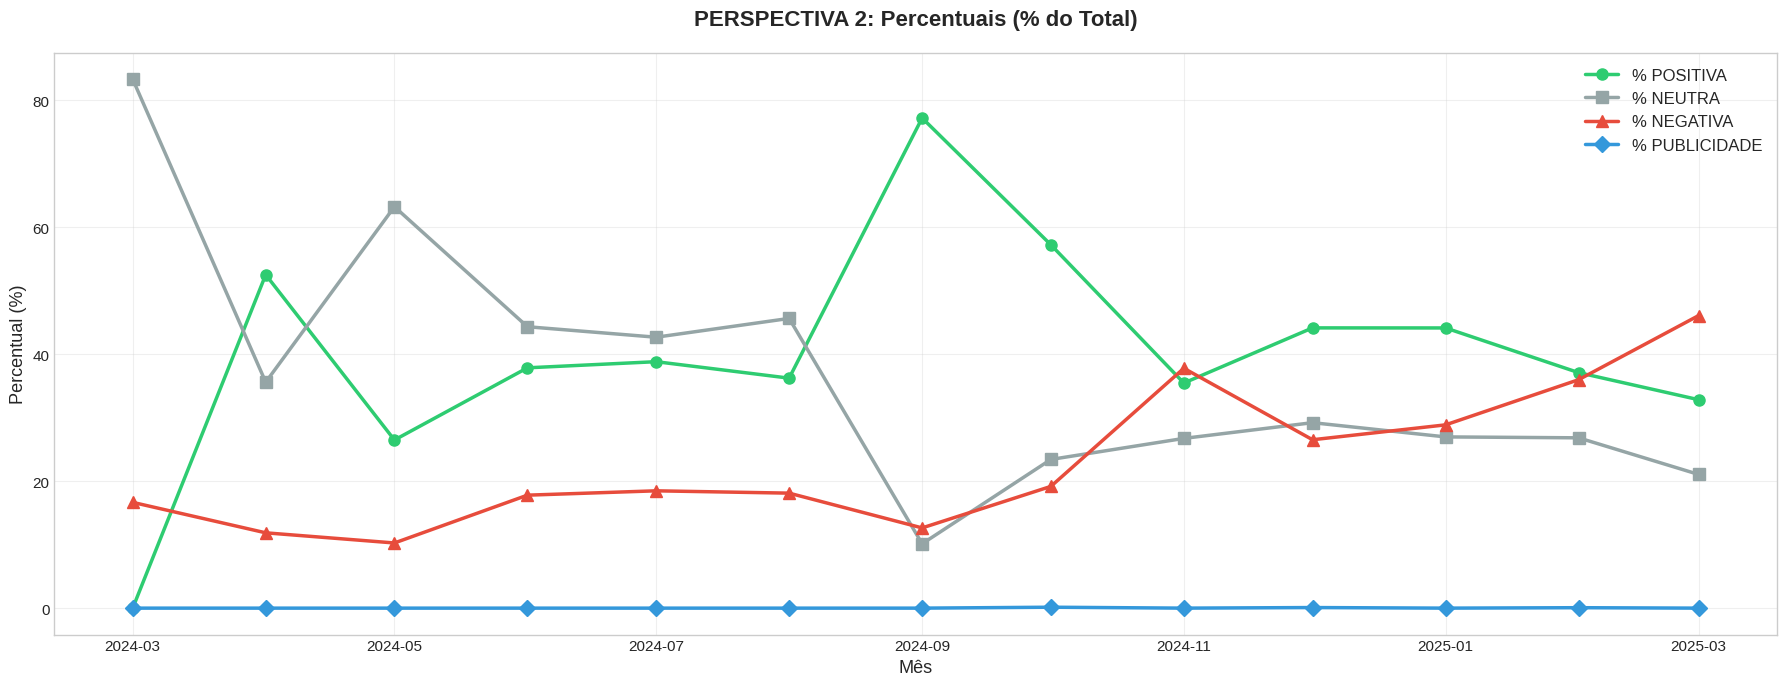

💡 INTERPRETAÇÃO:
   Mostra PROPORÇÃO
   Se % NEGATIVA caiu de 25%→22%: menos reclamações proporcionalmente
   Pesquisa vê isso e diz 'melhorou'


In [5]:
# Calcular percentuais
temporal_all['Pct_POSITIVA'] = (temporal_all['POSITIVA'] / temporal_all['Total_Geral'] * 100)
temporal_all['Pct_NEUTRA'] = (temporal_all['NEUTRA'] / temporal_all['Total_Geral'] * 100)
temporal_all['Pct_NEGATIVA'] = (temporal_all['NEGATIVA'] / temporal_all['Total_Geral'] * 100)
temporal_all['Pct_PUBLICIDADE'] = (temporal_all['PUBLICIDADE'] / temporal_all['Total_Geral'] * 100)

fig, ax = plt.subplots(figsize=(18, 7))

ax.plot(temporal_all['Data'], temporal_all['Pct_POSITIVA'], 
        marker='o', linewidth=2.5, markersize=8, color='#2ecc71', label='% POSITIVA')
ax.plot(temporal_all['Data'], temporal_all['Pct_NEUTRA'], 
        marker='s', linewidth=2.5, markersize=8, color='#95a5a6', label='% NEUTRA')
ax.plot(temporal_all['Data'], temporal_all['Pct_NEGATIVA'], 
        marker='^', linewidth=2.5, markersize=8, color='#e74c3c', label='% NEGATIVA')
ax.plot(temporal_all['Data'], temporal_all['Pct_PUBLICIDADE'], 
        marker='D', linewidth=2.5, markersize=8, color='#3498db', label='% PUBLICIDADE')

if setembro_2025_ts in temporal_all['Data'].values:
    ax.axvline(setembro_2025_ts, color='gold', linestyle=':', alpha=0.6, linewidth=3)

ax.set_title('PERSPECTIVA 2: Percentuais (% do Total)', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Mês', fontsize=13)
ax.set_ylabel('Percentual (%)', fontsize=13)
ax.legend(loc='best', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("💡 INTERPRETAÇÃO:")
print("   Mostra PROPORÇÃO")
print("   Se % NEGATIVA caiu de 25%→22%: menos reclamações proporcionalmente")
print("   Pesquisa vê isso e diz 'melhorou'")

## 4. PERSPECTIVA 3: Índice Base 100 ⭐ NOVO

**Responde:** "Qual classificação cresce mais rápido?"

**Para quem:** Análise estratégica de tendências

**Como funciona:** Primeiro mês = 100 para todas. Outros meses relativos a esse.

In [6]:
# Escolher mês de referência (primeiro mês com dados)
mes_base = temporal_all['Ano_Mes'].min()
print(f"📍 Mês de referência (Base 100): {mes_base}")

# Valores base
base_positiva = temporal_all[temporal_all['Ano_Mes'] == mes_base]['POSITIVA'].values[0]
base_neutra = temporal_all[temporal_all['Ano_Mes'] == mes_base]['NEUTRA'].values[0]
base_negativa = temporal_all[temporal_all['Ano_Mes'] == mes_base]['NEGATIVA'].values[0]
base_publicidade = temporal_all[temporal_all['Ano_Mes'] == mes_base]['PUBLICIDADE'].values[0]

# Calcular índices (evitar divisão por zero)
temporal_all['Indice_POSITIVA'] = (temporal_all['POSITIVA'] / base_positiva * 100) if base_positiva > 0 else 0
temporal_all['Indice_NEUTRA'] = (temporal_all['NEUTRA'] / base_neutra * 100) if base_neutra > 0 else 0
temporal_all['Indice_NEGATIVA'] = (temporal_all['NEGATIVA'] / base_negativa * 100) if base_negativa > 0 else 0
temporal_all['Indice_PUBLICIDADE'] = (temporal_all['PUBLICIDADE'] / base_publicidade * 100) if base_publicidade > 0 else 0

print(f"\nValores base ({mes_base}):")
print(f"   POSITIVA: {base_positiva:,.0f}")
print(f"   NEUTRA: {base_neutra:,.0f}")
print(f"   NEGATIVA: {base_negativa:,.0f}")
print(f"   PUBLICIDADE: {base_publicidade:,.0f}")

📍 Mês de referência (Base 100): 2024-03

Valores base (2024-03):
   POSITIVA: 0
   NEUTRA: 5
   NEGATIVA: 1
   PUBLICIDADE: 0


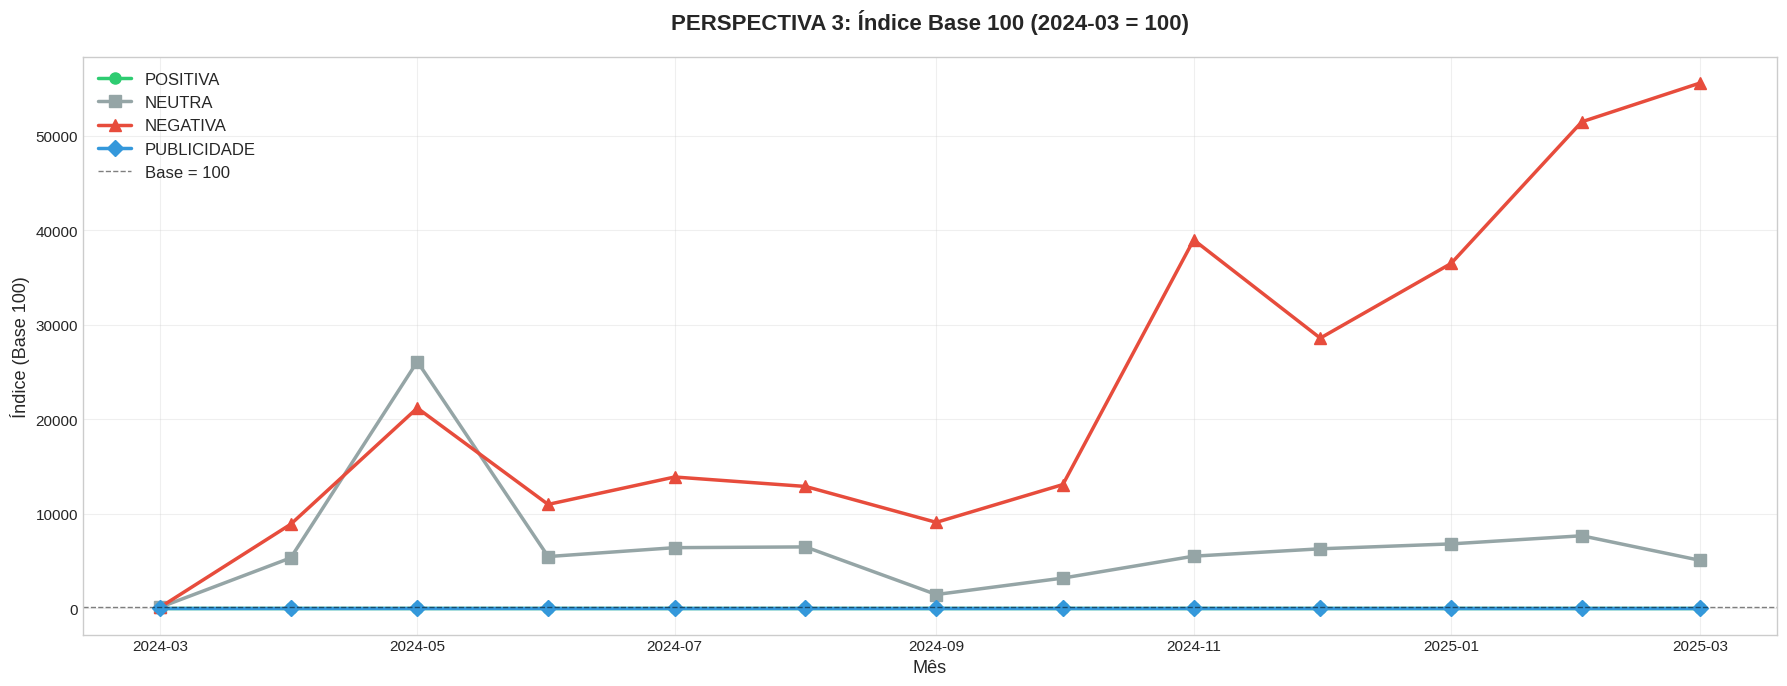

💡 INTERPRETAÇÃO:
   Compara TAXAS DE CRESCIMENTO
   Se POSITIVA está em 150 e NEGATIVA em 120:
   → POSITIVA cresceu 50%, NEGATIVA cresceu 20%
   → POSITIVA cresce MAIS RÁPIDO que NEGATIVA

   Se uma linha está ACIMA de outra:
   → Essa classificação cresceu MAIS desde o início


In [7]:
fig, ax = plt.subplots(figsize=(18, 7))

ax.plot(temporal_all['Data'], temporal_all['Indice_POSITIVA'], 
        marker='o', linewidth=2.5, markersize=8, color='#2ecc71', label='POSITIVA')
ax.plot(temporal_all['Data'], temporal_all['Indice_NEUTRA'], 
        marker='s', linewidth=2.5, markersize=8, color='#95a5a6', label='NEUTRA')
ax.plot(temporal_all['Data'], temporal_all['Indice_NEGATIVA'], 
        marker='^', linewidth=2.5, markersize=8, color='#e74c3c', label='NEGATIVA')
ax.plot(temporal_all['Data'], temporal_all['Indice_PUBLICIDADE'], 
        marker='D', linewidth=2.5, markersize=8, color='#3498db', label='PUBLICIDADE')

ax.axhline(100, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Base = 100')

if setembro_2025_ts in temporal_all['Data'].values:
    ax.axvline(setembro_2025_ts, color='gold', linestyle=':', alpha=0.6, linewidth=3)

ax.set_title(f'PERSPECTIVA 3: Índice Base 100 ({mes_base} = 100)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Mês', fontsize=13)
ax.set_ylabel('Índice (Base 100)', fontsize=13)
ax.legend(loc='best', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("💡 INTERPRETAÇÃO:")
print("   Compara TAXAS DE CRESCIMENTO")
print("   Se POSITIVA está em 150 e NEGATIVA em 120:")
print("   → POSITIVA cresceu 50%, NEGATIVA cresceu 20%")
print("   → POSITIVA cresce MAIS RÁPIDO que NEGATIVA")
print("\n   Se uma linha está ACIMA de outra:")
print("   → Essa classificação cresceu MAIS desde o início")

## 5. PERSPECTIVA 4: Taxa de Crescimento Mês a Mês ⭐ NOVO

**Responde:** "Mudança foi gradual ou abrupta?"

**Para quem:** Detecção de eventos/crises

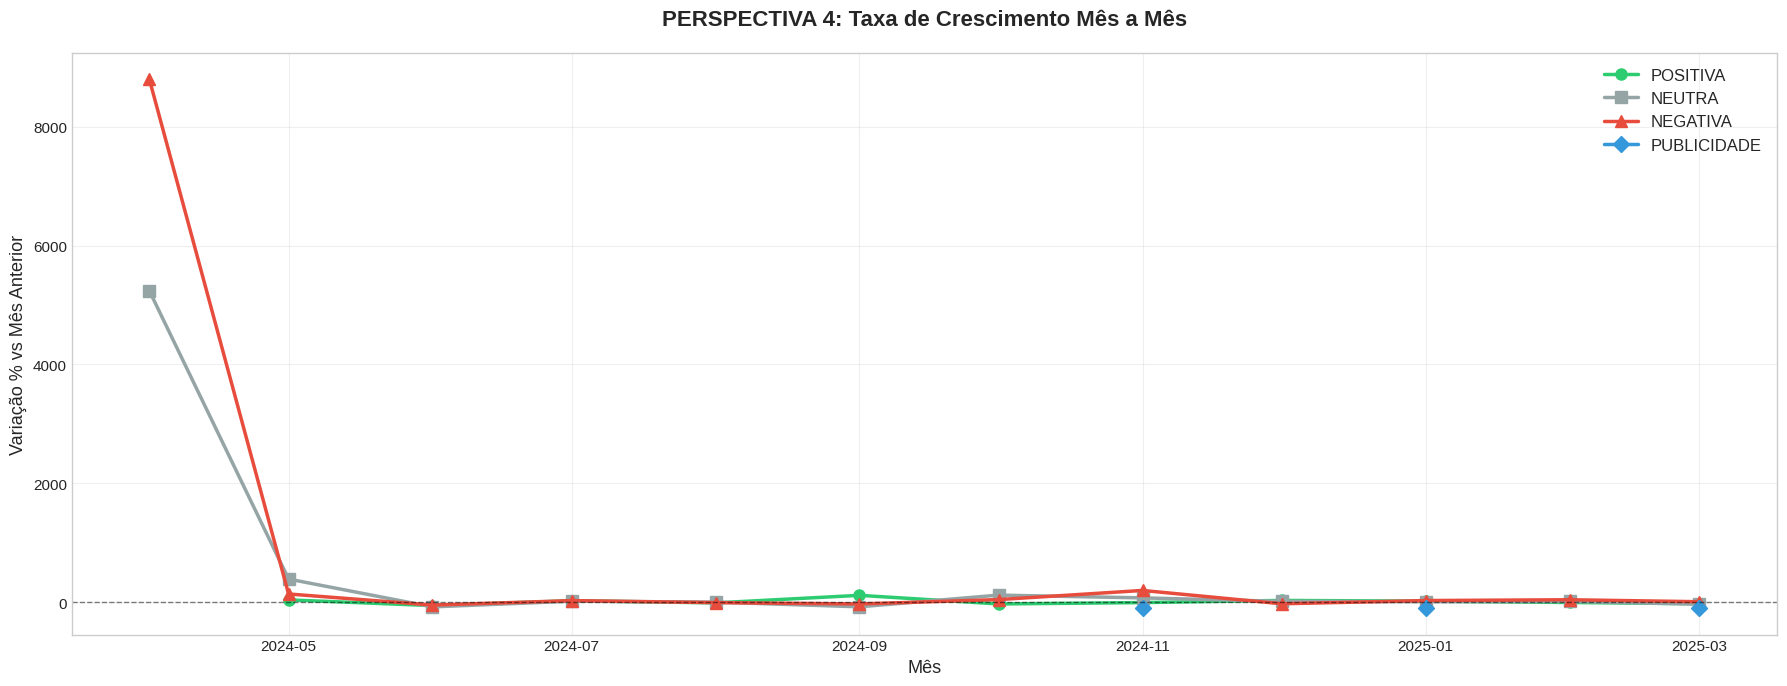

💡 INTERPRETAÇÃO:
   Mostra ACELERAÇÕES e DESACELERAÇÕES
   Valores positivos → Crescimento vs mês anterior
   Valores negativos → Queda vs mês anterior
   Picos grandes → Mudanças ABRUPTAS (eventos/crises)
   Valores próximos de zero → Estabilidade


In [8]:
# Calcular variação percentual mês a mês
temporal_all['Growth_POSITIVA'] = temporal_all['POSITIVA'].pct_change() * 100
temporal_all['Growth_NEUTRA'] = temporal_all['NEUTRA'].pct_change() * 100
temporal_all['Growth_NEGATIVA'] = temporal_all['NEGATIVA'].pct_change() * 100
temporal_all['Growth_PUBLICIDADE'] = temporal_all['PUBLICIDADE'].pct_change() * 100

fig, ax = plt.subplots(figsize=(18, 7))

ax.plot(temporal_all['Data'], temporal_all['Growth_POSITIVA'], 
        marker='o', linewidth=2.5, markersize=8, color='#2ecc71', label='POSITIVA')
ax.plot(temporal_all['Data'], temporal_all['Growth_NEUTRA'], 
        marker='s', linewidth=2.5, markersize=8, color='#95a5a6', label='NEUTRA')
ax.plot(temporal_all['Data'], temporal_all['Growth_NEGATIVA'], 
        marker='^', linewidth=2.5, markersize=8, color='#e74c3c', label='NEGATIVA')
ax.plot(temporal_all['Data'], temporal_all['Growth_PUBLICIDADE'], 
        marker='D', linewidth=2.5, markersize=8, color='#3498db', label='PUBLICIDADE')

ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)

if setembro_2025_ts in temporal_all['Data'].values:
    ax.axvline(setembro_2025_ts, color='gold', linestyle=':', alpha=0.6, linewidth=3)

ax.set_title('PERSPECTIVA 4: Taxa de Crescimento Mês a Mês', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Mês', fontsize=13)
ax.set_ylabel('Variação % vs Mês Anterior', fontsize=13)
ax.legend(loc='best', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("💡 INTERPRETAÇÃO:")
print("   Mostra ACELERAÇÕES e DESACELERAÇÕES")
print("   Valores positivos → Crescimento vs mês anterior")
print("   Valores negativos → Queda vs mês anterior")
print("   Picos grandes → Mudanças ABRUPTAS (eventos/crises)")
print("   Valores próximos de zero → Estabilidade")

## 6. PERSPECTIVA 5: Média Móvel (Tendência) ⭐ NOVO

**Responde:** "Tendência real ou só ruído?"

**Para quem:** Decisões estratégicas de longo prazo

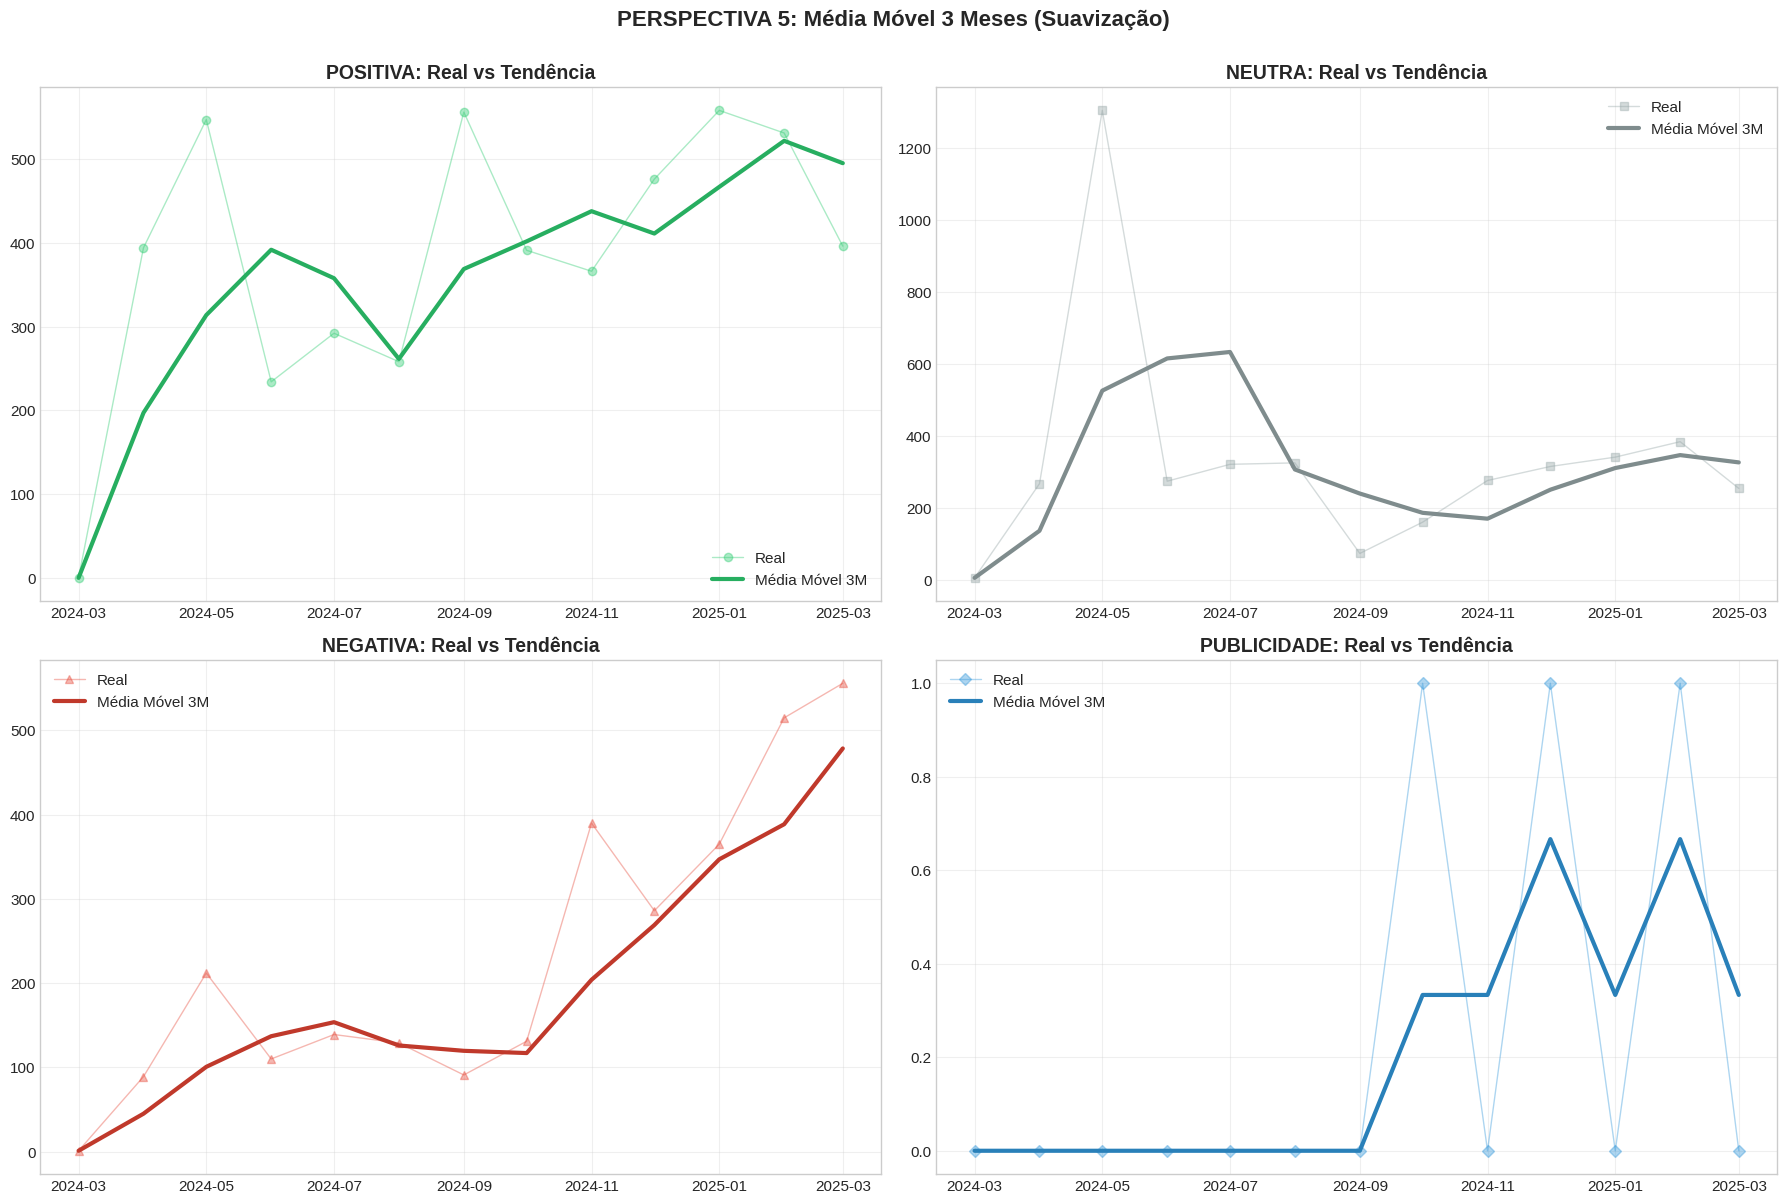

💡 INTERPRETAÇÃO:
   Linha fina (real) → Volatilidade mês a mês
   Linha grossa (média móvel) → Tendência de longo prazo
   Se tendência sobe → Melhoria sustentada
   Se tendência desce → Deterioração sustentada
   Se tendência plana → Estabilidade


In [9]:
# Média móvel de 3 meses
window = 3

temporal_all['MA3_POSITIVA'] = temporal_all['POSITIVA'].rolling(window=window, min_periods=1).mean()
temporal_all['MA3_NEUTRA'] = temporal_all['NEUTRA'].rolling(window=window, min_periods=1).mean()
temporal_all['MA3_NEGATIVA'] = temporal_all['NEGATIVA'].rolling(window=window, min_periods=1).mean()
temporal_all['MA3_PUBLICIDADE'] = temporal_all['PUBLICIDADE'].rolling(window=window, min_periods=1).mean()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# POSITIVA
axes[0, 0].plot(temporal_all['Data'], temporal_all['POSITIVA'], 
                marker='o', linewidth=1, alpha=0.4, color='#2ecc71', label='Real')
axes[0, 0].plot(temporal_all['Data'], temporal_all['MA3_POSITIVA'], 
                linewidth=3, color='#27ae60', label=f'Média Móvel {window}M')
if setembro_2025_ts in temporal_all['Data'].values:
    axes[0, 0].axvline(setembro_2025_ts, color='gold', linestyle=':', alpha=0.6)
axes[0, 0].set_title('POSITIVA: Real vs Tendência', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# NEUTRA
axes[0, 1].plot(temporal_all['Data'], temporal_all['NEUTRA'], 
                marker='s', linewidth=1, alpha=0.4, color='#95a5a6', label='Real')
axes[0, 1].plot(temporal_all['Data'], temporal_all['MA3_NEUTRA'], 
                linewidth=3, color='#7f8c8d', label=f'Média Móvel {window}M')
if setembro_2025_ts in temporal_all['Data'].values:
    axes[0, 1].axvline(setembro_2025_ts, color='gold', linestyle=':', alpha=0.6)
axes[0, 1].set_title('NEUTRA: Real vs Tendência', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# NEGATIVA
axes[1, 0].plot(temporal_all['Data'], temporal_all['NEGATIVA'], 
                marker='^', linewidth=1, alpha=0.4, color='#e74c3c', label='Real')
axes[1, 0].plot(temporal_all['Data'], temporal_all['MA3_NEGATIVA'], 
                linewidth=3, color='#c0392b', label=f'Média Móvel {window}M')
if setembro_2025_ts in temporal_all['Data'].values:
    axes[1, 0].axvline(setembro_2025_ts, color='gold', linestyle=':', alpha=0.6)
axes[1, 0].set_title('NEGATIVA: Real vs Tendência', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# PUBLICIDADE
axes[1, 1].plot(temporal_all['Data'], temporal_all['PUBLICIDADE'], 
                marker='D', linewidth=1, alpha=0.4, color='#3498db', label='Real')
axes[1, 1].plot(temporal_all['Data'], temporal_all['MA3_PUBLICIDADE'], 
                linewidth=3, color='#2980b9', label=f'Média Móvel {window}M')
if setembro_2025_ts in temporal_all['Data'].values:
    axes[1, 1].axvline(setembro_2025_ts, color='gold', linestyle=':', alpha=0.6)
axes[1, 1].set_title('PUBLICIDADE: Real vs Tendência', fontsize=14, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle(f'PERSPECTIVA 5: Média Móvel {window} Meses (Suavização)', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("💡 INTERPRETAÇÃO:")
print("   Linha fina (real) → Volatilidade mês a mês")
print("   Linha grossa (média móvel) → Tendência de longo prazo")
print("   Se tendência sobe → Melhoria sustentada")
print("   Se tendência desce → Deterioração sustentada")
print("   Se tendência plana → Estabilidade")

## 7. PERSPECTIVA 6: Z-Score (Padronização) ⭐ NOVO

**Responde:** "Como comparar classificações com escalas MUITO diferentes?"

**Para quem:** Comparação estatística rigorosa

**Como funciona:** Transforma todas para média=0, desvio padrão=1

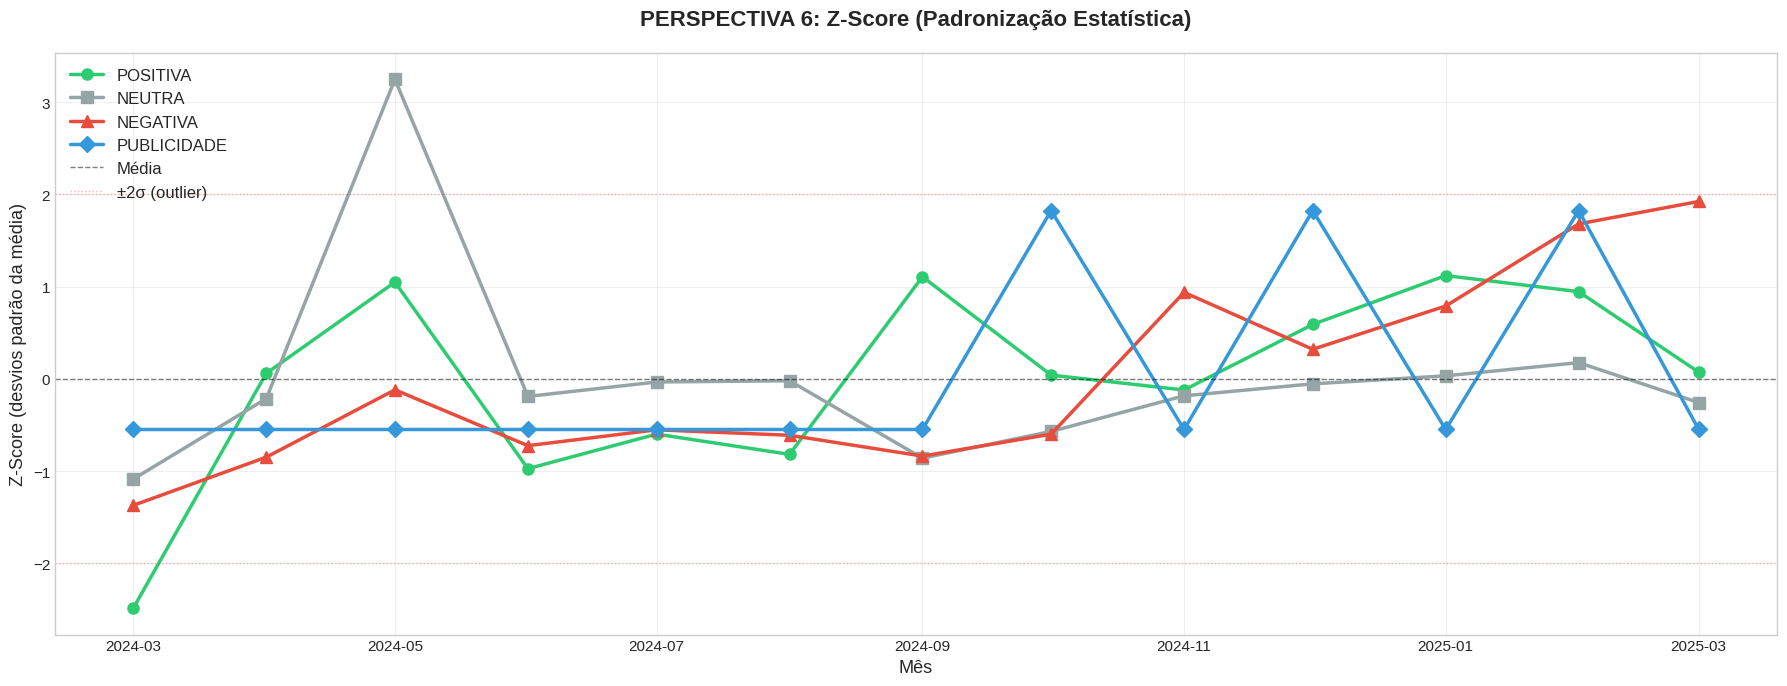

💡 INTERPRETAÇÃO:
   Todas as séries na MESMA ESCALA
   Z = 0  → Média histórica
   Z > 0  → Acima da média
   Z < 0  → Abaixo da média
   |Z| > 2 → OUTLIER (valor muito anormal)

   Permite comparar PUBLICIDADE (escala pequena) com POSITIVA (escala grande)


In [10]:
# Calcular Z-scores
temporal_all['Z_POSITIVA'] = stats.zscore(temporal_all['POSITIVA'])
temporal_all['Z_NEUTRA'] = stats.zscore(temporal_all['NEUTRA'])
temporal_all['Z_NEGATIVA'] = stats.zscore(temporal_all['NEGATIVA'])
temporal_all['Z_PUBLICIDADE'] = stats.zscore(temporal_all['PUBLICIDADE'])

fig, ax = plt.subplots(figsize=(18, 7))

ax.plot(temporal_all['Data'], temporal_all['Z_POSITIVA'], 
        marker='o', linewidth=2.5, markersize=8, color='#2ecc71', label='POSITIVA')
ax.plot(temporal_all['Data'], temporal_all['Z_NEUTRA'], 
        marker='s', linewidth=2.5, markersize=8, color='#95a5a6', label='NEUTRA')
ax.plot(temporal_all['Data'], temporal_all['Z_NEGATIVA'], 
        marker='^', linewidth=2.5, markersize=8, color='#e74c3c', label='NEGATIVA')
ax.plot(temporal_all['Data'], temporal_all['Z_PUBLICIDADE'], 
        marker='D', linewidth=2.5, markersize=8, color='#3498db', label='PUBLICIDADE')

ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Média')
ax.axhline(2, color='red', linestyle=':', linewidth=1, alpha=0.3, label='±2σ (outlier)')
ax.axhline(-2, color='red', linestyle=':', linewidth=1, alpha=0.3)

if setembro_2025_ts in temporal_all['Data'].values:
    ax.axvline(setembro_2025_ts, color='gold', linestyle=':', alpha=0.6, linewidth=3)

ax.set_title('PERSPECTIVA 6: Z-Score (Padronização Estatística)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Mês', fontsize=13)
ax.set_ylabel('Z-Score (desvios padrão da média)', fontsize=13)
ax.legend(loc='best', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("💡 INTERPRETAÇÃO:")
print("   Todas as séries na MESMA ESCALA")
print("   Z = 0  → Média histórica")
print("   Z > 0  → Acima da média")
print("   Z < 0  → Abaixo da média")
print("   |Z| > 2 → OUTLIER (valor muito anormal)")
print("\n   Permite comparar PUBLICIDADE (escala pequena) com POSITIVA (escala grande)")

## 8. Comparação Lado a Lado: Setembro

Vamos ver setembro em TODAS as perspectivas

In [11]:
setembro_mes = pd.Period('2025-09', freq='M')
agosto_mes = pd.Period('2025-08', freq='M')

dados_set = temporal_all[temporal_all['Ano_Mes'] == setembro_mes]
dados_ago = temporal_all[temporal_all['Ano_Mes'] == agosto_mes]

print("="*80)
print("SETEMBRO EM TODAS AS PERSPECTIVAS")
print("="*80)

if len(dados_set) > 0 and len(dados_ago) > 0:
    comparacao = []
    
    for class_name in ['POSITIVA', 'NEGATIVA', 'PUBLICIDADE']:
        # Absoluto
        abs_ago = dados_ago[class_name].values[0]
        abs_set = dados_set[class_name].values[0]
        delta_abs = abs_set - abs_ago
        
        # Percentual
        pct_ago = dados_ago[f'Pct_{class_name}'].values[0]
        pct_set = dados_set[f'Pct_{class_name}'].values[0]
        delta_pct = pct_set - pct_ago
        
        # Índice
        idx_ago = dados_ago[f'Indice_{class_name}'].values[0]
        idx_set = dados_set[f'Indice_{class_name}'].values[0]
        delta_idx = idx_set - idx_ago
        
        # Growth rate
        growth = dados_set[f'Growth_{class_name}'].values[0]
        
        # Z-score
        z_score = dados_set[f'Z_{class_name}'].values[0]
        
        comparacao.append({
            'Classificação': class_name,
            'Δ Absoluto': f"{delta_abs:+,.0f}",
            'Δ Percentual': f"{delta_pct:+.1f}pp",
            'Δ Índice': f"{delta_idx:+.1f}",
            'Growth Rate': f"{growth:+.1f}%",
            'Z-Score': f"{z_score:.2f}"
        })
    
    comp_df = pd.DataFrame(comparacao)
    display(comp_df)
    
    print("\n💡 LEITURA DA TABELA:")
    print("   Δ Absoluto    → Mudança em números brutos (comunicação)")
    print("   Δ Percentual  → Mudança em % do total (pesquisa)")
    print("   Δ Índice      → Mudança na taxa de crescimento")
    print("   Growth Rate   → Variação % vs agosto")
    print("   Z-Score       → Quão anormal é setembro (>2 = outlier)")
    
else:
    print("⚠️ Dados não disponíveis")

print("\n" + "="*80)

SETEMBRO EM TODAS AS PERSPECTIVAS
⚠️ Dados não disponíveis



## 9. Conclusão: Qual Perspectiva Usar?

### 🎯 Guia de Uso

| Pergunta | Perspectiva | Para Quem |
|----------|-------------|----------|
| "Quantas reclamações teve?" | Absolutos | Comunicação |
| "Satisfação melhorou?" | Percentuais | Pesquisa |
| "Qual cresce mais rápido?" | Índice Base 100 | Estratégia |
| "Foi mudança abrupta?" | Taxa de Crescimento | Detecção de eventos |
| "Tendência real ou ruído?" | Média Móvel | Decisões de longo prazo |
| "Comparar escalas diferentes?" | Z-Score | Análise estatística |

### 💡 Recomendação

**Use TODAS juntas!** Cada uma responde uma pergunta diferente.

**Exemplo:**
- Absolutos: Reclamações subiram 300
- Percentuais: % reclamações caiu 3pp
- Índice: POSITIVA cresceu 50%, NEGATIVA 20%
- Growth: Mudança foi gradual (não abrupta)
- Média móvel: Tendência de alta em POSITIVA
- Z-score: Setembro não é outlier

**Conclusão integrada:** Volume aumentou (ambos cresceram), mas POSITIVA cresceu MAIS RÁPIDO que NEGATIVA, resultando em melhoria proporcional. Mudança foi gradual, não evento pontual.

---

## 10. Exportar Resultados

In [12]:
# Exportar dataset completo
temporal_all.to_csv('analise_temporal_multiplas_perspectivas.csv', index=False)

print("✅ Arquivo exportado:")
print("   - analise_temporal_multiplas_perspectivas.csv")
print("\n🎉 Análise completa com múltiplas perspectivas concluída!")

✅ Arquivo exportado:
   - analise_temporal_multiplas_perspectivas.csv

🎉 Análise completa com múltiplas perspectivas concluída!
